In [8]:
# Imports

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, top_k_accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
import timm
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [9]:
# Config

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
IMAGES_DIR = DATA_DIR / "images"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cpu")

MODEL_NAME = "convnextv2_tiny.fcmae_ft_in22k_in1k"
IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0

NUM_EPOCHS_HEAD = 3
NUM_EPOCHS_FINE = 2

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 5e-6
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 2

OTHERS_CONFIDENCE_THRESHOLD = 0.10

print("Model:", MODEL_NAME)
print("Device:", DEVICE)

Model: convnextv2_tiny.fcmae_ft_in22k_in1k
Device: cpu


In [10]:
#Dataset check

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

class_folders = sorted([p for p in IMAGES_DIR.iterdir() if p.is_dir()])

for class_dir in class_folders:
    class_name = class_dir.name
    for file_path in class_dir.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            records.append({
                "filepath": str(file_path),
                "class_name": class_name
            })

df = pd.DataFrame(records)

class_names = sorted(df["class_name"].unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["class_name"].map(class_to_idx)

print("Classes :", len(class_names))
print("Images  :", len(df))
print(df["class_name"].value_counts().head())

Classes : 216
Images  : 3922
class_name
others                  800
deadly_fibrecap          16
amanita_gemmata          15
amethyst_chanterelle     15
amethyst_deceiver        15
Name: count, dtype: int64


In [11]:
# Image verify

def verify_image(filepath):
    try:
        with Image.open(filepath) as img:
            img.verify()
        with Image.open(filepath) as img:
            img.convert("RGB")
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

mask = []
for path in tqdm(df["filepath"], total=len(df)):
    mask.append(verify_image(path))

df = df[np.array(mask)].reset_index(drop=True)

print("Valid images:", len(df))
print("Classes after cleaning:", df['class_name'].nunique())

  0%|          | 0/3922 [00:00<?, ?it/s]

Valid images: 3922
Classes after cleaning: 216


In [12]:
# Dataset split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class_name"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("Train classes:", train_df["class_name"].nunique())
print("Val classes  :", val_df["class_name"].nunique())
print("Test classes :", test_df["class_name"].nunique())

Train: 2745 | Val: 588 | Test: 589
Train classes: 216
Val classes  : 206
Test classes : 207


In [13]:
# Dataset transform and loading

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.70, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random")
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class MushroomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = int(row["label"])
        return image, label

train_dataset = MushroomDataset(train_df, train_transform)
val_dataset = MushroomDataset(val_df, eval_transform)
test_dataset = MushroomDataset(test_df, eval_transform)

train_class_counts = train_df["label"].value_counts().to_dict()
sample_weights = train_df["label"].map(lambda x: 1.0 / train_class_counts[x]).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))

Train batches: 344


In [14]:
# Model definition

NUM_CLASSES = len(class_names)

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

print("Model ready.")
print("Classes:", NUM_CLASSES)

Model ready.
Classes: 216


In [15]:
# Helper functions

train_class_counts_series = train_df["label"].value_counts().sort_index()
class_weights = []

for i in range(NUM_CLASSES):
    count = train_class_counts_series.get(i, 1)
    class_weights.append(1.0 / count)

class_weights = np.array(class_weights, dtype=np.float32)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.03
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

def topk_acc(logits, targets, k=3):
    k = min(k, logits.size(1))
    topk = torch.topk(logits, k=k, dim=1).indices
    return topk.eq(targets.view(-1, 1)).sum().item() / targets.size(0)

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []
    total_top3 = 0.0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        bs = labels.size(0)
        running_loss += loss.item() * bs
        total += bs
        total_top3 += topk_acc(outputs, labels, k=3) * bs

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    return {
        "loss": running_loss / total,
        "acc": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "top3": total_top3 / total,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

history = {"phase1": [], "phase2": []}
best_val_loss = float("inf")
best_model_state = None

In [16]:
# Phase 1 training

patience_counter = 0

for epoch in range(1, NUM_EPOCHS_HEAD + 1):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_one_epoch(model, val_loader, criterion, None)

    scheduler.step(val_metrics["loss"])

    history["phase1"].append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["f1"],
        "val_top3": val_metrics["top3"],
    })

    print(
        f"Phase1 Epoch {epoch} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f} | "
        f"val_top3={val_metrics['top3']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        break

model.load_state_dict(best_model_state)

  0%|          | 0/344 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

Phase1 Epoch 1 | train_loss=3.0770 | val_loss=2.3796 | val_acc=0.4184 | val_top3=0.5595


  0%|          | 0/344 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

Phase1 Epoch 2 | train_loss=1.1444 | val_loss=1.8759 | val_acc=0.5544 | val_top3=0.7177


  0%|          | 0/344 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

Phase1 Epoch 3 | train_loss=0.7905 | val_loss=1.7147 | val_acc=0.6003 | val_top3=0.7449


<All keys matched successfully>

In [17]:
# Phase 2 training

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE_FINE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

patience_counter = 0

for epoch in range(1, NUM_EPOCHS_FINE + 1):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_one_epoch(model, val_loader, criterion, None)

    scheduler.step(val_metrics["loss"])

    history["phase2"].append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["f1"],
        "val_top3": val_metrics["top3"],
    })

    print(
        f"Phase2 Epoch {epoch} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f} | "
        f"val_top3={val_metrics['top3']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        break

model.load_state_dict(best_model_state)

  0%|          | 0/344 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

Phase2 Epoch 1 | train_loss=0.5462 | val_loss=1.5370 | val_acc=0.6514 | val_top3=0.7721


  0%|          | 0/344 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

Phase2 Epoch 2 | train_loss=0.4836 | val_loss=1.4957 | val_acc=0.6667 | val_top3=0.7755


<All keys matched successfully>

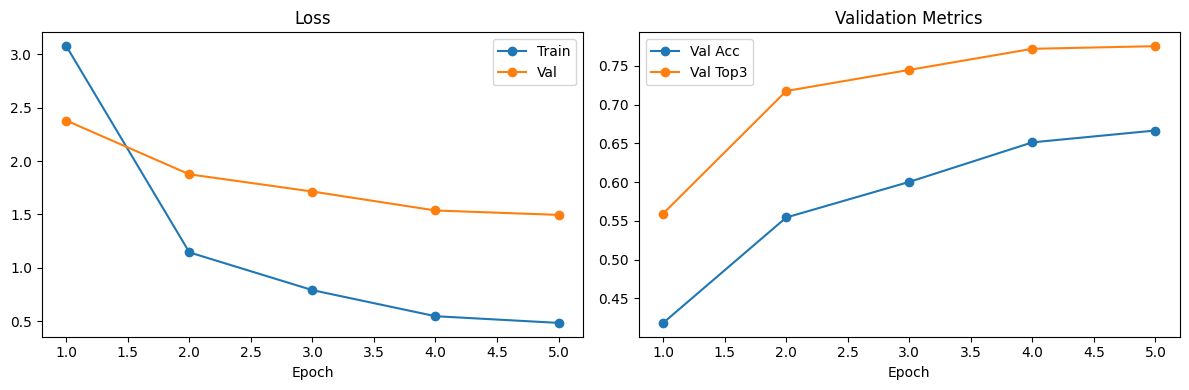

In [18]:
# Train plot

phase1_df = pd.DataFrame(history["phase1"])
phase2_df = pd.DataFrame(history["phase2"])

rows = []
if len(phase1_df):
    temp = phase1_df.copy()
    temp["global_epoch"] = range(1, len(temp) + 1)
    rows.append(temp)

if len(phase2_df):
    temp = phase2_df.copy()
    temp["global_epoch"] = range(len(phase1_df) + 1, len(phase1_df) + len(phase2_df) + 1)
    rows.append(temp)

hist_df = pd.concat(rows, ignore_index=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_df["global_epoch"], hist_df["train_loss"], marker="o", label="Train")
plt.plot(hist_df["global_epoch"], hist_df["val_loss"], marker="o", label="Val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_df["global_epoch"], hist_df["val_acc"], marker="o", label="Val Acc")
plt.plot(hist_df["global_epoch"], hist_df["val_top3"], marker="o", label="Val Top3")
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# Model evaluation

test_metrics = run_one_epoch(model, test_loader, criterion, None)

print("Test loss :", round(test_metrics["loss"], 4))
print("Test acc  :", round(test_metrics["acc"], 4))
print("Test f1   :", round(test_metrics["f1"], 4))
print("Test top3 :", round(test_metrics["top3"], 4))

y_true = test_metrics["labels"]
y_pred = test_metrics["preds"]
y_prob = test_metrics["probs"]

present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))

report = classification_report(
    y_true,
    y_pred,
    labels=present_labels,
    target_names=[idx_to_class[i] for i in present_labels],
    zero_division=0
)

print(report[:3000])

  0%|          | 0/74 [00:00<?, ?it/s]

Test loss : 1.4219
Test acc  : 0.6486
Test f1   : 0.6332
Test top3 : 0.7844
                          precision    recall  f1-score   support

         almond_mushroom       0.50      1.00      0.67         1
         amanita_gemmata       0.00      0.00      0.00         1
    amethyst_chanterelle       0.50      0.50      0.50         4
       amethyst_deceiver       0.50      1.00      0.67         1
          aniseed_funnel       1.00      1.00      1.00         2
               ascot_hat       0.75      0.75      0.75         4
              bay_bolete       0.67      1.00      0.80         2
         bearded_milkcap       1.00      0.33      0.50         3
      beechwood_sickener       0.75      1.00      0.86         3
        beefsteak_fungus       1.00      1.00      1.00         1
          birch_polypore       1.00      0.75      0.86         4
          birch_woodwart       1.00      1.00      1.00         2
     bitter_beech_bolete       1.00      0.25      0.40         4

In [20]:
# Saving files

FINAL_MODEL_PATH = OUTPUT_DIR / "best_model.pth"
CLASS_NAMES_PATH = OUTPUT_DIR / "class_names.json"
CONFIG_PATH = OUTPUT_DIR / "inference_config.json"

torch.save(model.state_dict(), FINAL_MODEL_PATH)

ordered_class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(ordered_class_names, f, indent=2, ensure_ascii=False)

config = {
    "model_name": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "num_classes": len(ordered_class_names),
    "normalization": {
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD
    },
    "others_class_name": "others",
    "others_threshold": OTHERS_CONFIDENCE_THRESHOLD
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Saved:")
print(FINAL_MODEL_PATH)
print(CLASS_NAMES_PATH)
print(CONFIG_PATH)

Saved:
c:\Users\VirtualUser\Desktop\Abraham_Internship\Mushroom_Classifier\outputs\best_model.pth
c:\Users\VirtualUser\Desktop\Abraham_Internship\Mushroom_Classifier\outputs\class_names.json
c:\Users\VirtualUser\Desktop\Abraham_Internship\Mushroom_Classifier\outputs\inference_config.json


In [21]:
# Inference on random image

inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def predict_single_image(image_path, top_k=3, threshold=OTHERS_CONFIDENCE_THRESHOLD):
    image = Image.open(image_path).convert("RGB")
    x = inference_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    top_idx = np.argsort(probs)[::-1][:top_k]
    pred_idx = int(top_idx[0])

    raw_pred = ordered_class_names[pred_idx]
    conf = float(probs[pred_idx])
    final_pred = raw_pred if conf >= threshold else "others"

    top_preds = [(ordered_class_names[i], float(probs[i])) for i in top_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Pred: {final_pred}\nConf: {conf:.2f}")
    plt.axis("off")
    plt.show()

    print("Raw prediction :", raw_pred)
    print("Final prediction:", final_pred)
    print("Top predictions :", top_preds)

# Example:
# predict_single_image(r"test_image.jpg")

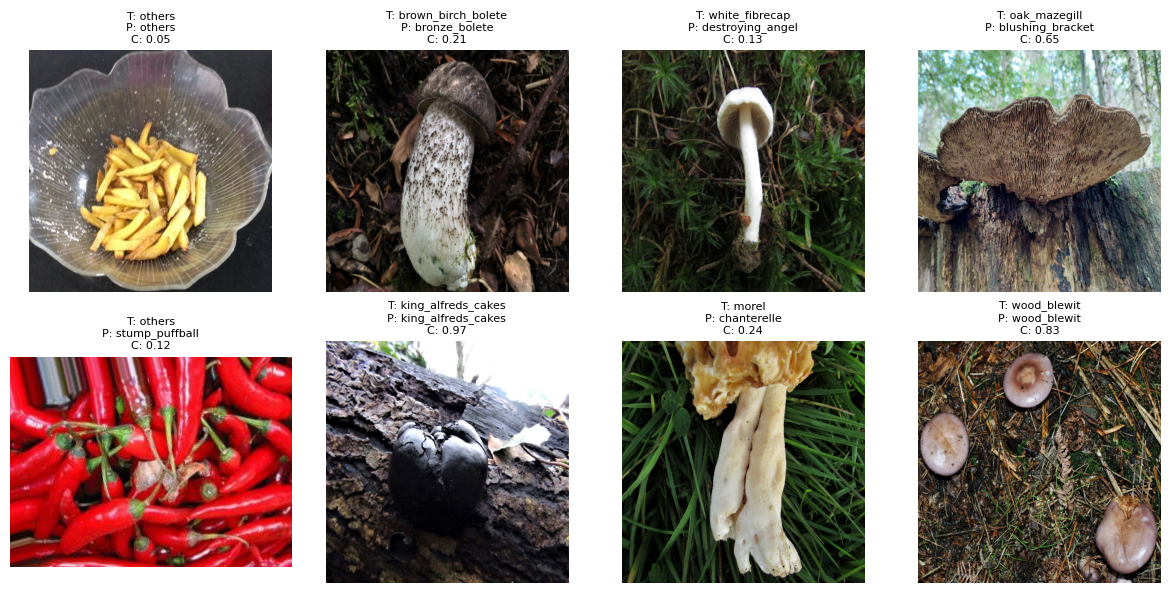

In [22]:
# Batch inference

def show_batch_predictions(dataframe, n=8, threshold=OTHERS_CONFIDENCE_THRESHOLD):
    sample_df = dataframe.sample(min(n, len(dataframe)), random_state=SEED).reset_index(drop=True)

    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))
    plt.figure(figsize=(12, 6))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        image = Image.open(row["filepath"]).convert("RGB")
        x = inference_transform(image).unsqueeze(0).to(DEVICE)

        model.eval()
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = int(np.argmax(probs))
        raw_pred = ordered_class_names[pred_idx]
        conf = float(probs[pred_idx])
        final_pred = raw_pred if conf >= threshold else "others"

        plt.subplot(rows, cols, i)
        plt.imshow(image)
        plt.title(f"T: {row['class_name']}\nP: {final_pred}\nC: {conf:.2f}", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch_predictions(test_df, n=8)